# 47.3 · Rigid alignment and ICP

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain rigid alignment and icp using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[44 · 3D Computer Vision](../../44-3d-computer-vision/README.md), [46 · Stereo Vision](../../46-stereo-vision/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

A point cloud is a set of 3D samples, often with color, normals or confidence. Unlike an image, it has no guaranteed regular grid. Sampling density, outliers and coordinate conventions affect every downstream geometric operation.

## 2. Intuition

With known pairs, Kabsch alignment finds the least-squares rigid rotation and translation through SVD and reflection correction. ICP alternates nearest-neighbor assignment and rigid fitting. It needs a reasonable initialization and can converge to a wrong local alignment on symmetric or partially overlapping shapes.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 47
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
\min_{R,t}\sum_i\lVert Rp_i+t-q_i\rVert^2
$$

pi and qi are paired 3D points, R a proper rotation and t translation. If every target equals its source plus [1,0,0], identity rotation and that translation give zero residual.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
source = np.array([[0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])
translation = np.array([1.0, 0.0, 0.0])
target = source + translation
residual = np.linalg.norm(source + translation - target, axis=1)
assert np.allclose(residual, 0)
print(residual)

[0. 0. 0.]


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The lab compares exact paired rigid fitting with iterative unpaired ICP and plots voxel-reduced points. The optional Open3D workflow reads and writes real point-cloud files.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def point_clouds(lesson=0, seed=42, amount=1.0):
    rng = np.random.default_rng(seed)
    target = rng.uniform(-1, 1, (250, 3))
    target[:, 2] *= 0.3
    angle = 0.06 * amount
    r = np.array([[np.cos(angle), -np.sin(angle), 0], [np.sin(angle), np.cos(angle), 0], [0, 0, 1]])
    source = target @ r.T + [0.06, 0.04, 0.03]
    aligned, errors = icp(source, target, iterations=20)
    sampled = voxel_downsample(aligned, 0.18 * amount)
    rr, tt = rigid_fit(source, target)
    return Result(
        "47 · Point cloud alignment and sampling",
        points={"Source": source, "Aligned": aligned, "Voxel means": sampled},
        curves={"ICP nearest-neighbor mean distance": errors},
        metrics={
            "input_points": len(source),
            "voxel_points": len(sampled),
            "paired_rigid_rmse": float(np.sqrt(np.mean((source @ rr.T + tt - target) ** 2))),
        },
        notes="ICP uses nearest neighbors and can converge to a local minimum. The paired Kabsch result is a separate easier problem with known correspondences. Units are arbitrary scene units.",
    )

{
  "input_points": 250,
  "voxel_points": 202,
  "paired_rigid_rmse": 2.6091000372606417e-16
}
ICP uses nearest neighbors and can converge to a local minimum. The paired Kabsch result is a separate easier problem with known correspondences. Units are arbitrary scene units.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/geometry.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.geometry import icp

display(Code(inspect.getsource(icp), language="python"))

def icp(source, target, iterations=15):
    """Point-to-point ICP; depends on a reasonable initial alignment."""
    aligned = np.array(source, float, copy=True)
    tree = cKDTree(target)
    errors = []
    for _ in range(iterations):
        distances, indices = tree.query(aligned)
        r, t = rigid_fit(aligned, target[indices])
        aligned = aligned @ r.T + t
        errors.append(float(np.mean(distances)))
    return aligned, errors

## 8. Experiment

Increase initial rotation and partial overlap to find ICP failures. Compare point count and geometric detail at several voxel sizes.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "input_points": 250,
    "voxel_points": 202,
    "paired_rigid_rmse": 2.6091000372606417e-16
  },
  "second_seed": {
    "input_points": 250,
    "voxel_points": 203,
    "paired_rigid_rmse": 1.808988808631182e-16
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

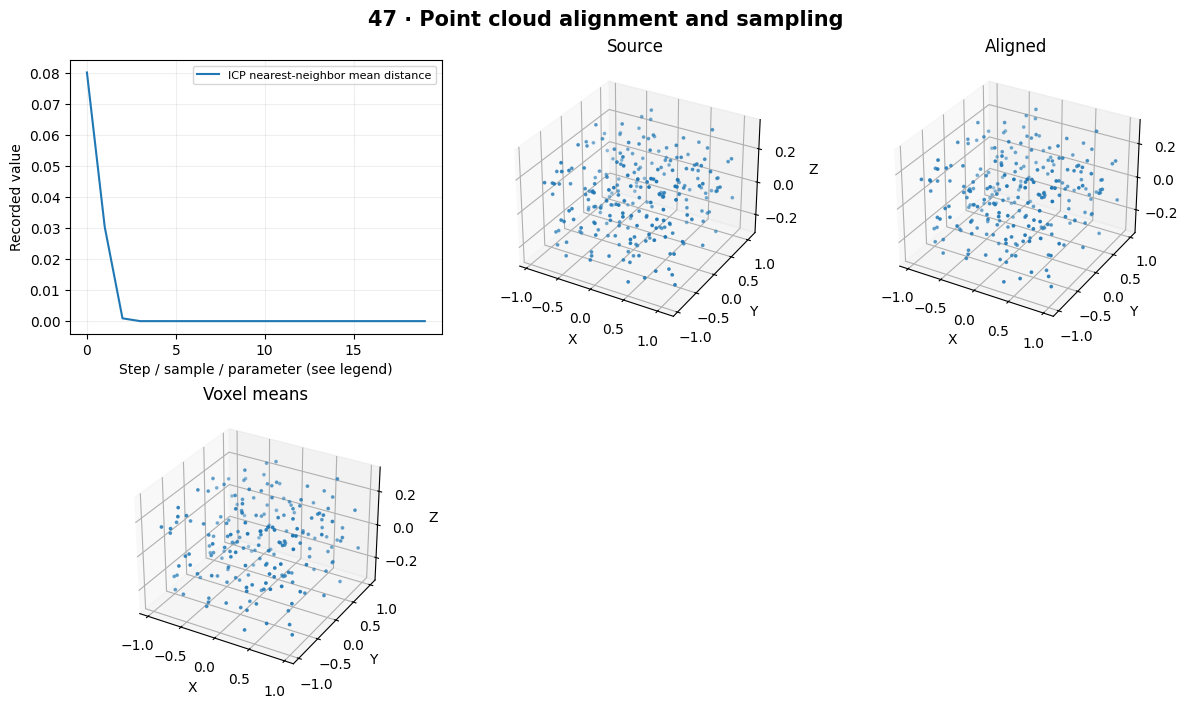

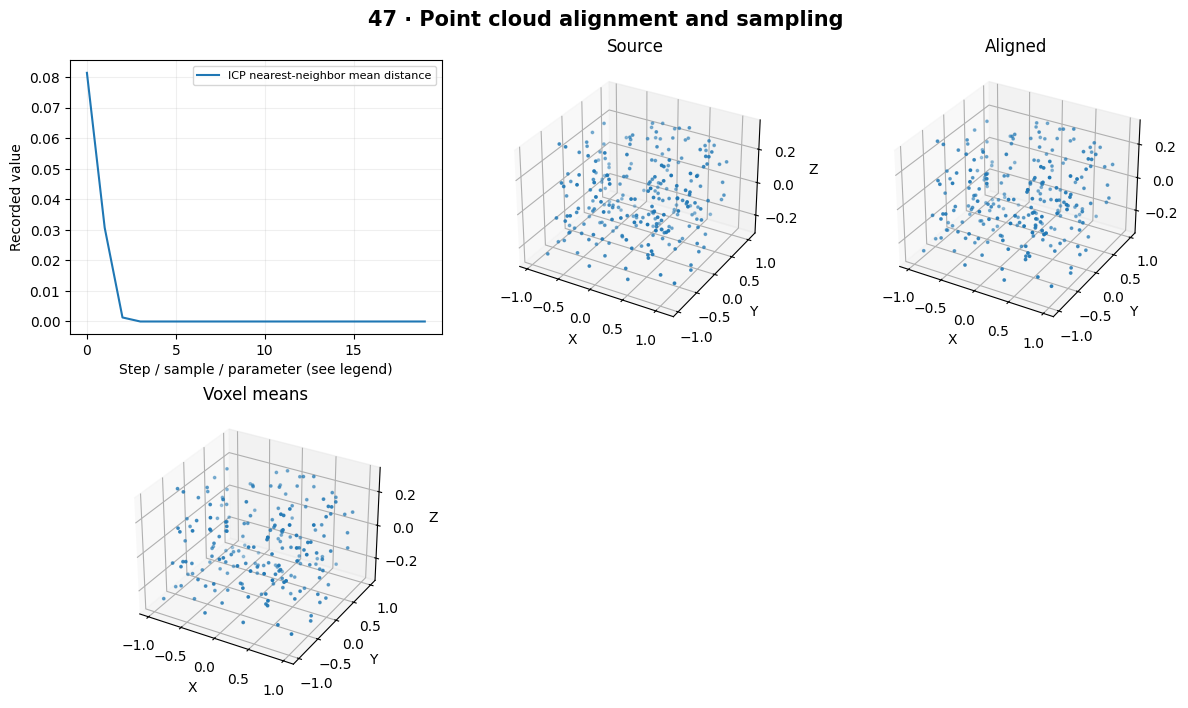

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Point Cloud Workshop**. Construct and inspect point clouds with units and frame labels. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

ICP residual can be small for an incorrect symmetric alignment. Voxel size has physical units and must match the cloud scale.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Increase initial rotation and partial overlap to find ICP failures. Compare point count and geometric detail at several voxel sizes.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a point-cloud registration tool that reports overlap, residuals and transform conventions and visualizes failed alignments.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

With known pairs, Kabsch alignment finds the least-squares rigid rotation and translation through SVD and reflection correction. ICP alternates nearest-neighbor assignment and rigid fitting. It needs a reasonable initialization and can converge to a wrong local alignment on symmetric or partially overlapping shapes.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[48 · Neural Radiance Fields](../../48-neural-radiance-fields/README.md)

[Primary reference](https://www.open3d.org/docs/release/tutorial/pipelines/icp_registration.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)